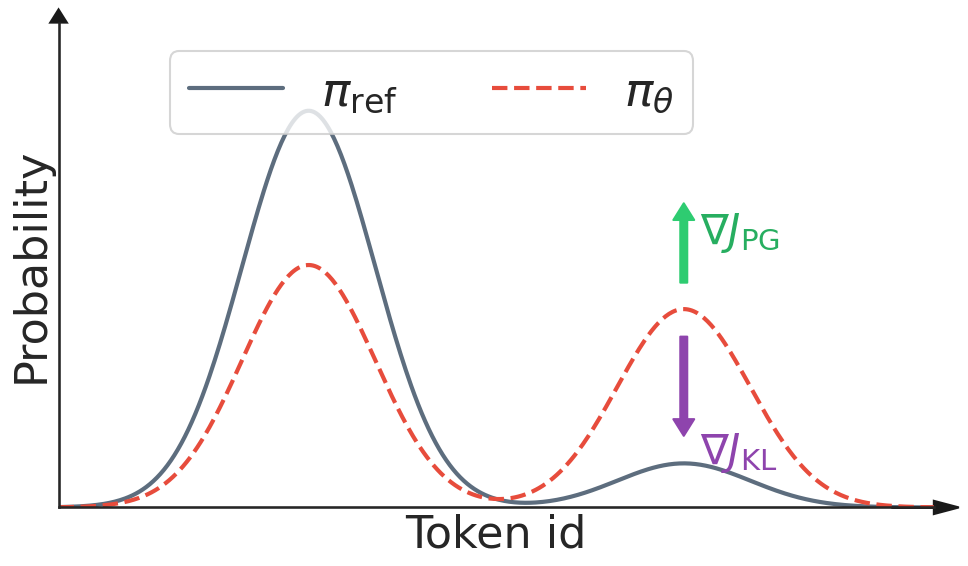

In [187]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 设置 Seaborn 风格 (白色背景，无网格)
sns.set_theme(style="white", context="talk")
np.random.seed(42)
# 2. 生成模拟数据 (双峰分布)
x = np.linspace(0, 105, 500) #稍微延长x轴以便画箭头

def gaussian(x, mu, sig, height):
    return height * np.exp(-np.power(x - mu, 2.) / (2 * np.power(sig, 2.)))

# Pi_ref: 左峰高，右峰低 (模型原本的分布)
# 右侧峰值较低，代表参考模型不太生成这个token
base_y = 0.1
y_ref = gaussian(x, 30, 8, 1-base_y) + gaussian(x, 75, 8, base_y)

# Pi_theta: 左峰变低，右峰变高 (经过RL训练后的分布)
# 右侧峰值变高，说明模型很想生成这个token (可能是因为Reward高)
peak_y = 0.45
y_theta = gaussian(x, 30, 8, 1-peak_y) + gaussian(x, 75, 8, peak_y)

# 3. 开始绘图
fig, ax = plt.subplots(figsize=(10, 6))

# 绘制曲线
sns.lineplot(x=x, y=y_ref, label=r'$\pi_{\text{ref}}$', linewidth=3, color='#34495e', alpha=0.8)
sns.lineplot(x=x, y=y_theta, label=r'$\pi_{\theta}$', linewidth=3, color='#e74c3c', linestyle='--')

# 4. 绘制箭头 (核心逻辑)
# 关注区域在右侧峰值 (x=75左右)
target_x = 75
# peak_y = 0.75 # pi_theta 的高度
# base_y = 0.2  # pi_ref 的高度

# 箭头 1: Nabla J(theta) (向上，代表 Reward 让概率增加)
# 我们把它画在峰值上方一点，指向上
ax.annotate(
    '', 
    xy=(target_x, peak_y + 0.25),   # 箭头尖端位置
    xytext=(target_x, peak_y + 0.05), # 箭头尾部位置
    arrowprops=dict(facecolor='#2ecc71', edgecolor='#2ecc71', shrink=0.05, width=5, headwidth=15)
)
# 添加文字标签
ax.text(target_x + 2, peak_y + 0.15, r'$\nabla J_{\text{PG}}$', color='#27ae60', fontsize=30, fontweight='bold')

# 箭头 2: Nabla J_KL (向下，代表 KL Penalty 想把概率拉回 ref)
# 画在两个分布之间，指向下，表示受到压制
ax.annotate(
    '', 
    xy=(target_x, base_y + 0.05),     # 箭头尖端位置 (指向ref)
    xytext=(target_x, peak_y - 0.05), # 箭头尾部位置 (从theta出发)
    arrowprops=dict(facecolor='#8e44ad', edgecolor='#8e44ad', shrink=0.05, width=5, headwidth=15)
)
# 添加文字标签
ax.text(target_x + 2, base_y, r'$\nabla J_{\text{KL}}$', color='#8e44ad', fontsize=30, fontweight='bold')

# 5. 坐标轴与美化处理
# 移除顶部和右侧的边框 (Spines)
sns.despine()
ax.arrow(100, 0, 5, 0, head_width=0.03, head_length=3, fc='k', ec='k', clip_on=False)
# Y轴箭头
ax.arrow(0, 1.1, 0, 0.0, head_width=2, head_length=0.03, fc='k', ec='k', clip_on=False)
# 设置标签
ax.set_xlabel("Token id", fontsize=32, ) # label放右边
ax.set_ylabel("Probability", fontsize=32,) # label放上边

# 移除刻度数字 (Ticks)，保留坐标轴线
ax.set_xticks([])
ax.set_yticks([])

# 设置坐标轴范围，确保只显示第一象限且紧凑
ax.set_xlim(0, 105)
ax.set_ylim(0, 1.1)

# 调整图例位置
plt.legend(frameon=True, loc='upper left', bbox_to_anchor=(0.1, 0.99), ncols=2, fontsize=34)

# 显示图像
plt.tight_layout()
plt.show()

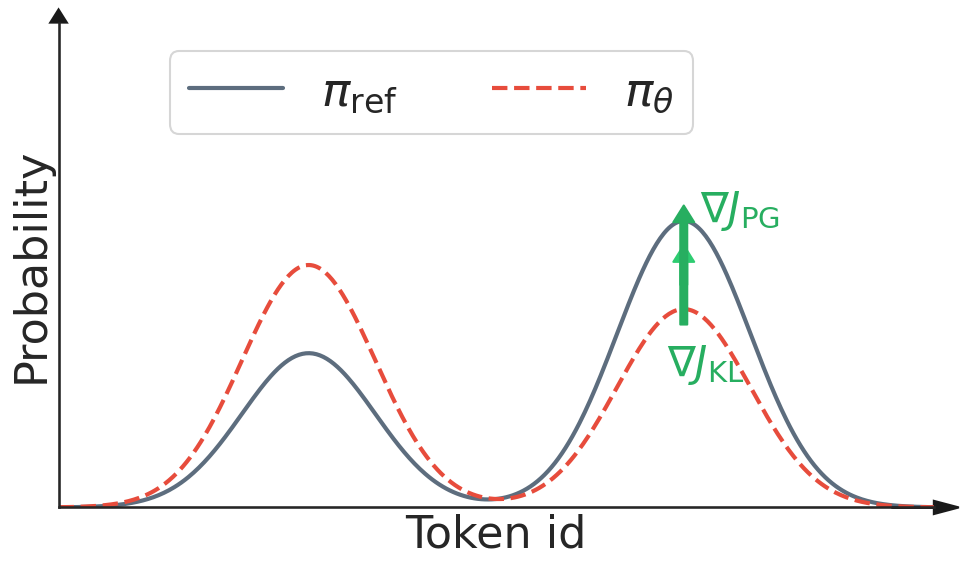

In [183]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 设置 Seaborn 风格 (白色背景，无网格)
sns.set_theme(style="white", context="talk")
np.random.seed(42)
# 2. 生成模拟数据 (双峰分布)
x = np.linspace(0, 105, 500) #稍微延长x轴以便画箭头

def gaussian(x, mu, sig, height):
    return height * np.exp(-np.power(x - mu, 2.) / (2 * np.power(sig, 2.)))

# Pi_ref: 左峰高，右峰低 (模型原本的分布)
# 右侧峰值较低，代表参考模型不太生成这个token
base_y = 0.65
y_ref = gaussian(x, 30, 8, 1-base_y) + gaussian(x, 75, 8, base_y)

# Pi_theta: 左峰变低，右峰变高 (经过RL训练后的分布)
# 右侧峰值变高，说明模型很想生成这个token (可能是因为Reward高)
peak_y = 0.45
y_theta = gaussian(x, 30, 8, 1-peak_y) + gaussian(x, 75, 8, peak_y)

# 3. 开始绘图
fig, ax = plt.subplots(figsize=(10, 6))

# 绘制曲线
sns.lineplot(x=x, y=y_ref, label=r'$\pi_{\text{ref}}$', linewidth=3, color='#34495e', alpha=0.8)
sns.lineplot(x=x, y=y_theta, label=r'$\pi_{\theta}$', linewidth=3, color='#e74c3c', linestyle='--')

# 4. 绘制箭头 (核心逻辑)
# 关注区域在右侧峰值 (x=75左右)
target_x = 75
# peak_y = 0.75 # pi_theta 的高度
# base_y = 0.2  # pi_ref 的高度

# 箭头 1: Nabla J(theta) (向上，代表 Reward 让概率增加)
# 我们把它画在峰值上方一点，指向上
ax.annotate(
    '', 
    xy=(target_x, peak_y + 0.15),   # 箭头尖端位置
    xytext=(target_x, peak_y + 0.05), # 箭头尾部位置
    arrowprops=dict(facecolor='#2ecc71', edgecolor='#2ecc71', shrink=0.05, width=5, headwidth=15)
)
# 添加文字标签
ax.text(target_x + 2, peak_y + 0.2, r'$\nabla J_{\text{PG}}$', color='#27ae60', fontsize=30, fontweight='bold')

# 箭头 2: Nabla J_KL (向下，代表 KL Penalty 想把概率拉回 ref)
# 画在两个分布之间，指向下，表示受到压制
ax.annotate(
    '', 
    xy=(target_x, base_y + 0.05),     # 箭头尖端位置 (指向ref)
    xytext=(target_x, peak_y - 0.05), # 箭头尾部位置 (从theta出发)
    arrowprops=dict(facecolor='#27ae60', edgecolor='#27ae60', shrink=0.05, width=5, headwidth=15)
)
# 添加文字标签
ax.text(target_x - 2, peak_y-0.15, r'$\nabla J_{\text{KL}}$', color='#27ae60', fontsize=30, fontweight='bold')

# 5. 坐标轴与美化处理
# 移除顶部和右侧的边框 (Spines)
sns.despine()
ax.arrow(100, 0, 5, 0, head_width=0.03, head_length=3, fc='k', ec='k', clip_on=False)
# Y轴箭头
ax.arrow(0, 1.1, 0, 0.0, head_width=2, head_length=0.03, fc='k', ec='k', clip_on=False)
# 设置标签
ax.set_xlabel("Token id", fontsize=32, ) # label放右边
ax.set_ylabel("Probability", fontsize=32,) # label放上边

# 移除刻度数字 (Ticks)，保留坐标轴线
ax.set_xticks([])
ax.set_yticks([])

# 设置坐标轴范围，确保只显示第一象限且紧凑
ax.set_xlim(0, 105)
ax.set_ylim(0, 1.1)

# 调整图例位置
plt.legend(frameon=True, loc='upper left', bbox_to_anchor=(0.1, 0.99), ncols=2, fontsize=34)

# 显示图像
plt.tight_layout()
plt.show()

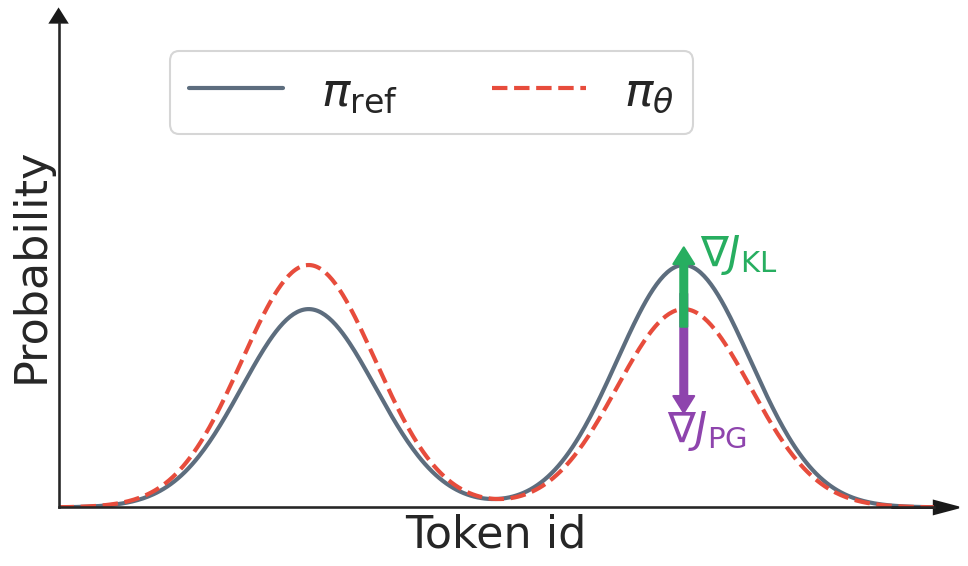

In [172]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 设置 Seaborn 风格 (白色背景，无网格)
sns.set_theme(style="white", context="talk")
np.random.seed(42)
# 2. 生成模拟数据 (双峰分布)
x = np.linspace(0, 105, 500) #稍微延长x轴以便画箭头

def gaussian(x, mu, sig, height):
    return height * np.exp(-np.power(x - mu, 2.) / (2 * np.power(sig, 2.)))

# Pi_ref: 左峰高，右峰低 (模型原本的分布)
# 右侧峰值较低，代表参考模型不太生成这个token
base_y = 0.65
y_ref = gaussian(x, 30, 8, 1-base_y) + gaussian(x, 75, 8, base_y)

# Pi_theta: 左峰变低，右峰变高 (经过RL训练后的分布)
# 右侧峰值变高，说明模型很想生成这个token (可能是因为Reward高)
peak_y = 0.45
y_theta = gaussian(x, 30, 8, 1-peak_y) + gaussian(x, 75, 8, peak_y)

# 3. 开始绘图
fig, ax = plt.subplots(figsize=(10, 6))

# 绘制曲线
sns.lineplot(x=x, y=y_ref, label=r'$\pi_{\text{ref}}$', linewidth=3, color='#34495e', alpha=0.8)
sns.lineplot(x=x, y=y_theta, label=r'$\pi_{\theta}$', linewidth=3, color='#e74c3c', linestyle='--')

# 4. 绘制箭头 (核心逻辑)
# 关注区域在右侧峰值 (x=75左右)
target_x = 75
# peak_y = 0.75 # pi_theta 的高度
# base_y = 0.2  # pi_ref 的高度

# 箭头 1: Nabla J(theta) (向上，代表 Reward 让概率增加)
# 我们把它画在峰值上方一点，指向上
ax.annotate(
    '', 
    xy=(target_x, peak_y - 0.25),   # 箭头尖端位置
    xytext=(target_x, peak_y + 0.05), # 箭头尾部位置
    arrowprops=dict(facecolor='#8e44ad', edgecolor='#8e44ad', shrink=0.05, width=5, headwidth=15)
)
# 添加文字标签
ax.text(target_x-2 , peak_y - 0.3, r'$\nabla J_{\text{PG}}$', color='#8e44ad', fontsize=30, fontweight='bold')

# 箭头 2: Nabla J_KL (向下，代表 KL Penalty 想把概率拉回 ref)
# 画在两个分布之间，指向下，表示受到压制
ax.annotate(
    '', 
    xy=(target_x, base_y + 0.05),     # 箭头尖端位置 (指向ref)
    xytext=(target_x, peak_y - 0.05), # 箭头尾部位置 (从theta出发)
    arrowprops=dict(facecolor='#27ae60', edgecolor='#27ae60', shrink=0.05, width=5, headwidth=15)
)
# 添加文字标签
ax.text(target_x + 2, base_y, r'$\nabla J_{\text{KL}}$', color='#27ae60', fontsize=30, fontweight='bold')

# 5. 坐标轴与美化处理
# 移除顶部和右侧的边框 (Spines)
sns.despine()
ax.arrow(100, 0, 5, 0, head_width=0.03, head_length=3, fc='k', ec='k', clip_on=False)
# Y轴箭头
ax.arrow(0, 1.1, 0, 0.0, head_width=2, head_length=0.03, fc='k', ec='k', clip_on=False)
# 设置标签
ax.set_xlabel("Token id", fontsize=32, ) # label放右边
ax.set_ylabel("Probability", fontsize=32,) # label放上边

# 移除刻度数字 (Ticks)，保留坐标轴线
ax.set_xticks([])
ax.set_yticks([])

# 设置坐标轴范围，确保只显示第一象限且紧凑
ax.set_xlim(0, 105)
ax.set_ylim(0, 1.1)

# 调整图例位置
plt.legend(frameon=True, loc='upper left', bbox_to_anchor=(0.1, 0.99), ncols=2, fontsize=34)

# 显示图像
plt.tight_layout()
plt.show()

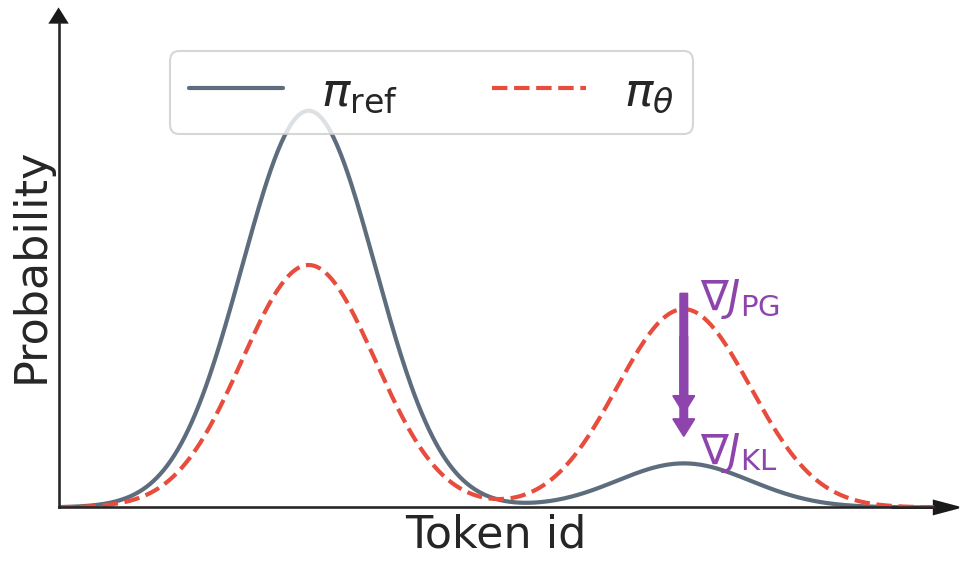

In [174]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 设置 Seaborn 风格 (白色背景，无网格)
sns.set_theme(style="white", context="talk")
np.random.seed(42)
# 2. 生成模拟数据 (双峰分布)
x = np.linspace(0, 105, 500) #稍微延长x轴以便画箭头

def gaussian(x, mu, sig, height):
    return height * np.exp(-np.power(x - mu, 2.) / (2 * np.power(sig, 2.)))

# Pi_ref: 左峰高，右峰低 (模型原本的分布)
# 右侧峰值较低，代表参考模型不太生成这个token
base_y = 0.1
y_ref = gaussian(x, 30, 8, 1-base_y) + gaussian(x, 75, 8, base_y)

# Pi_theta: 左峰变低，右峰变高 (经过RL训练后的分布)
# 右侧峰值变高，说明模型很想生成这个token (可能是因为Reward高)
peak_y = 0.45
y_theta = gaussian(x, 30, 8, 1-peak_y) + gaussian(x, 75, 8, peak_y)

# 3. 开始绘图
fig, ax = plt.subplots(figsize=(10, 6))

# 绘制曲线
sns.lineplot(x=x, y=y_ref, label=r'$\pi_{\text{ref}}$', linewidth=3, color='#34495e', alpha=0.8)
sns.lineplot(x=x, y=y_theta, label=r'$\pi_{\theta}$', linewidth=3, color='#e74c3c', linestyle='--')

# 4. 绘制箭头 (核心逻辑)
# 关注区域在右侧峰值 (x=75左右)
target_x = 75
# peak_y = 0.75 # pi_theta 的高度
# base_y = 0.2  # pi_ref 的高度

# 箭头 1: Nabla J(theta) (向上，代表 Reward 让概率增加)
# 我们把它画在峰值上方一点，指向上
ax.annotate(
    '', 
    xy=(target_x, peak_y - 0.25),   # 箭头尖端位置
    xytext=(target_x, peak_y + 0.05), # 箭头尾部位置
    arrowprops=dict(facecolor='#8e44ad', edgecolor='#8e44ad', shrink=0.05, width=5, headwidth=15)
)
# 添加文字标签
ax.text(target_x+2 , peak_y , r'$\nabla J_{\text{PG}}$', color='#8e44ad', fontsize=30, fontweight='bold')

# 箭头 2: Nabla J_KL (向下，代表 KL Penalty 想把概率拉回 ref)
# 画在两个分布之间，指向下，表示受到压制
ax.annotate(
    '', 
    xy=(target_x, base_y + 0.05),     # 箭头尖端位置 (指向ref)
    xytext=(target_x, peak_y - 0.05), # 箭头尾部位置 (从theta出发)
    arrowprops=dict(facecolor='#8e44ad', edgecolor='#8e44ad', shrink=0.05, width=5, headwidth=15)
)
# 添加文字标签
ax.text(target_x + 2, base_y, r'$\nabla J_{\text{KL}}$', color='#8e44ad', fontsize=30, fontweight='bold')

# 5. 坐标轴与美化处理
# 移除顶部和右侧的边框 (Spines)
sns.despine()
ax.arrow(100, 0, 5, 0, head_width=0.03, head_length=3, fc='k', ec='k', clip_on=False)
# Y轴箭头
ax.arrow(0, 1.1, 0, 0.0, head_width=2, head_length=0.03, fc='k', ec='k', clip_on=False)
# 设置标签
ax.set_xlabel("Token id", fontsize=32, ) # label放右边
ax.set_ylabel("Probability", fontsize=32,) # label放上边

# 移除刻度数字 (Ticks)，保留坐标轴线
ax.set_xticks([])
ax.set_yticks([])

# 设置坐标轴范围，确保只显示第一象限且紧凑
ax.set_xlim(0, 105)
ax.set_ylim(0, 1.1)

# 调整图例位置
plt.legend(frameon=True, loc='upper left', bbox_to_anchor=(0.1, 0.99), ncols=2, fontsize=34)

# 显示图像
plt.tight_layout()
plt.show()

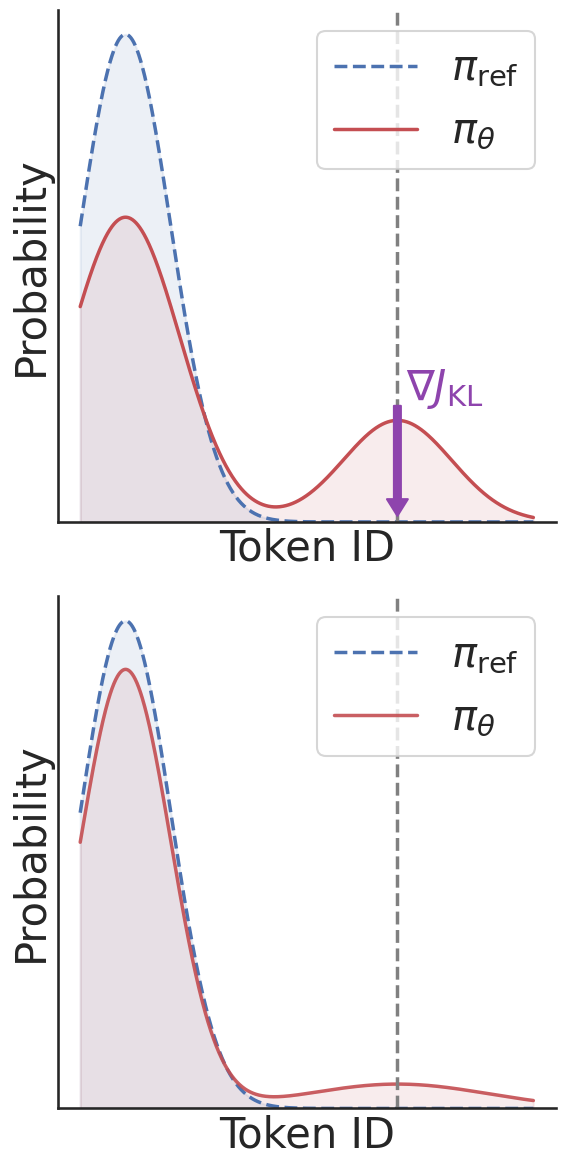

In [225]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

# ==========================================
# 1. 数据生成配置
# ==========================================
x = np.linspace(0, 100, 1000)

ref_peak1 = 10
theta_peak2 = 70

y_ref = norm.pdf(x, loc=ref_peak1, scale=10)
y_theta_bad = 0.75 * norm.pdf(x, loc=ref_peak1, scale=12) + \
              0.25 * norm.pdf(x, loc=theta_peak2, scale=12)
y_theta_good = norm.pdf(x, loc=ref_peak1, scale=10) * 0.9 + \
               norm.pdf(x, loc=theta_peak2, scale=20) * 0.1

# ==========================================
# 2. 绘图设置
# ==========================================
sns.set_style("white")
# 不再使用 set_context，而是手动控制字体大小
fontsize = 30  # <<< 统一字体大小

fig, axes = plt.subplots(2, 1, figsize=(6, 12))

color_ref = "#4c72b0"
color_theta = "#c44e52"

# --- 第一个子图 ---
ax1 = axes[0]
ax1.plot(x, y_ref, color=color_ref, linestyle='--', linewidth=2.5, label=r'$\pi_{\rm ref}$')
ax1.plot(x, y_theta_bad, color=color_theta, linewidth=2.5, label=r'$\pi_{\theta}$')
ax1.fill_between(x, y_ref, color=color_ref, alpha=0.1)
ax1.fill_between(x, y_theta_bad, color=color_theta, alpha=0.1)
ax1.legend(fontsize=fontsize)
ax1.annotate(
    '', 
    xy=(theta_peak2, 0),     # 箭头尖端位置 (指向ref)
    xytext=(theta_peak2, 0.01), # 箭头尾部位置 (从theta出发)
    arrowprops=dict(facecolor='#8e44ad', edgecolor='#8e44ad', shrink=0.05, width=5, headwidth=15)
)
# 添加文字标签
ax1.text(theta_peak2 + 2, 0.01, r'$\nabla J_{\text{KL}}$', color='#8e44ad', fontsize=30, fontweight='bold')


ax1.set_xlabel("Token ID", fontsize=fontsize)
ax1.set_ylabel("Probability", fontsize=fontsize)

# --- 第二个子图 ---
ax2 = axes[1]
ax2.plot(x, y_ref, color=color_ref, linestyle='--', linewidth=2.5, label=r'$\pi_{\rm ref}$')
ax2.plot(x, y_theta_good, color=color_theta, linewidth=2.5, alpha=0.9, label=r'$\pi_{\theta}$')
ax2.fill_between(x, y_ref, color=color_ref, alpha=0.1)
ax2.fill_between(x, y_theta_good, color=color_theta, alpha=0.1)
ax2.legend(fontsize=fontsize)
ax2.set_xlabel("Token ID", fontsize=fontsize)
ax2.set_ylabel("Probability", fontsize=fontsize)

# ==========================================
# 3. 全局样式调整
# ==========================================
for ax in axes:
    ax.set_ylim(0)
    ax.axvline(theta_peak2, linestyle='--', color='gray', linewidth=2.5)
    ax.set_xticks([])
    ax.set_yticks([])
    sns.despine(ax=ax)
    ax.grid(False)

plt.tight_layout()
plt.show()